**Load the Dataset**

In [247]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("imdb-movies-dataset.csv")
df.head()

,Poster,Title,Year,Certificate,Duration,Genre,Rating,Metascore,Director,Cast,VotesCount,Description,ReviewCount,Review Title,Review
0,https://m.media-amazon.com/images/M/MV5BYWRkZj...,The Idea of You,2023.0,R,115.0,"Comedy, Drama, Romance",6.4,67.0,Michael Showalter,"Anne Hathaway, Nicholas Galitzine, Ella Rubin,...","28,744","Solène, a 40-year-old single mom, begins an un...",166,Hypocrisy as an idea,"This film, as well as the reaction to it, is a..."
1,https://m.media-amazon.com/images/M/MV5BZGI4NT...,Kingdom of the Planet of the Apes,2023.0,PG-13,145.0,"Action, Adventure, Sci-Fi",7.3,66.0,Wes Ball,"Owen Teague, Freya Allan, Kevin Durand, Peter ...","22,248","Many years after the reign of Caesar, a young ...",183,A phenomenal start to another trilogy!,"I'm a big fan of all the planet of the apes, a..."
2,https://m.media-amazon.com/images/M/MV5BZjIyOT...,Unfrosted,2023.0,PG-13,97.0,"Biography, Comedy, History",5.5,42.0,Jerry Seinfeld,"Isaac Bae, Jerry Seinfeld, Chris Rickett, Rach...","18,401","In 1963 Michigan, business rivals Kellogg's an...",333,not funny,Pretty much the worst criticism you can lay on...
3,https://m.media-amazon.com/images/M/MV5BMjA5Zj...,The Fall Guy,2023.0,PG-13,126.0,"Action, Comedy, Drama",7.3,73.0,David Leitch,"Ryan Gosling, Emily Blunt, Aaron Taylor-Johnso...","38,953",A down-and-out stuntman must find the missing ...,384,Everything you needed and more!,Just got out of the Austin premier at SXSW and...
4,https://m.media-amazon.com/images/M/MV5BNTk1MT...,Challengers,2023.0,R,131.0,"Drama, Romance, Sport",7.7,82.0,Luca Guadagnino,"Zendaya, Mike Faist, Josh O'Connor, Darnell Ap...","32,517","Tashi, a former tennis prodigy turned coach, t...",194,"Watch ""Match Point"" instead",This is a tough one. I liked the concept and t...


In [248]:
df.shape

(10000, 15)

Data Preprocessing

In [249]:
df.isnull().sum()
df = df.dropna() 
df.columns = df.columns.str.strip()

In [250]:
#show how many duplicts data
duplicate_count = df.duplicated(subset='Title').sum()
duplicate_count

np.int64(159)

In [251]:



##remove duplicts
df = df.drop_duplicates(subset='Title', keep='first')
duplicate_count = df.duplicated(subset='Title').sum()
duplicate_count

np.int64(0)

Convert data types

In [252]:

df['VotesCount'] = df['VotesCount'].str.replace(',', '', regex=False).astype(int)
df['ReviewCount'] = df['ReviewCount'].str.replace(',', '', regex=False).astype(int)
df['Year'] = df['Year'].astype(int)
df['Rating'] = df['Rating'].astype(float)
df['Metascore'] = df['Metascore'].astype(int)
df['Duration'] = df['Duration'].astype(int)
df['Title'] = df['Title'].astype(str)

**Data Visualization**


**Pairplots using seaborn**

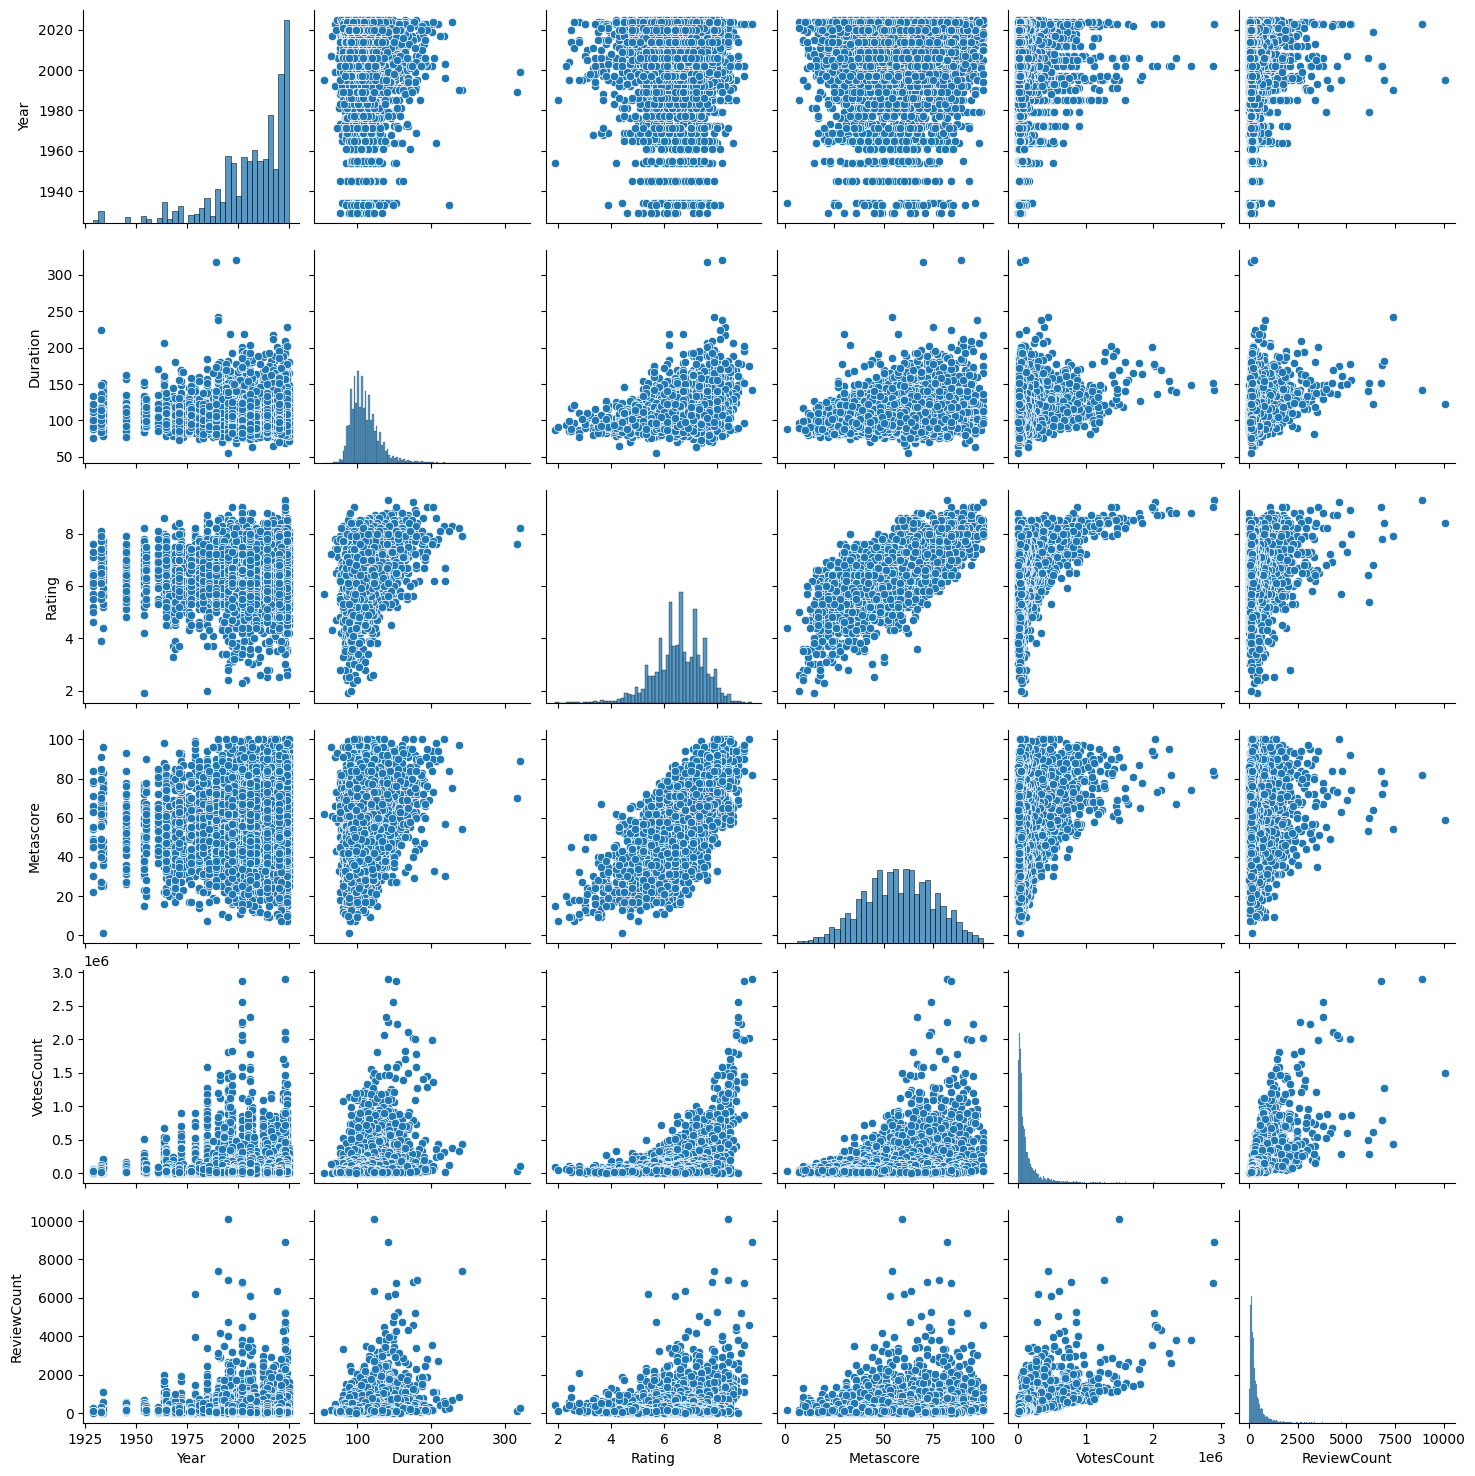

In [253]:
sns.pairplot(df)
plt.show()

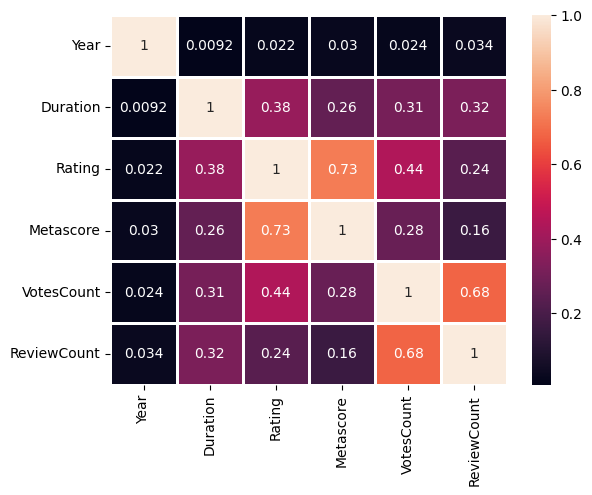

In [254]:
numeric_df=df.select_dtypes(include=['float64', 'int64'])
numeric_df.corr()
sns.heatmap(numeric_df.corr(),annot=True,linewidths=1)
plt.show()

In [255]:
##from above heatmap it show that i will use duration and metascore and votescount

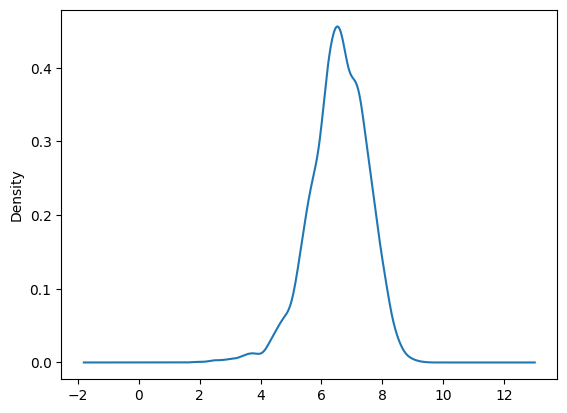

In [256]:
df['Rating'].plot.density()
plt.show()

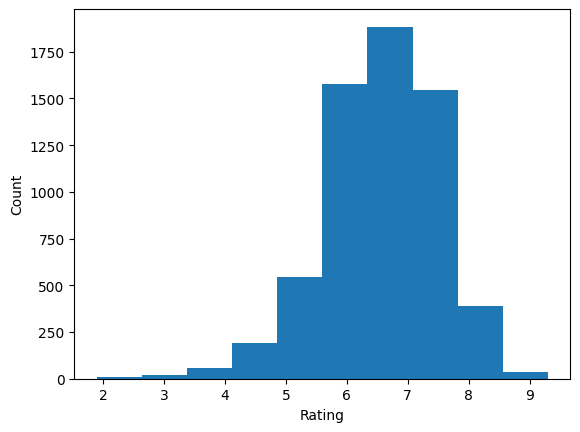

In [257]:


plt.hist(df['Rating'])
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


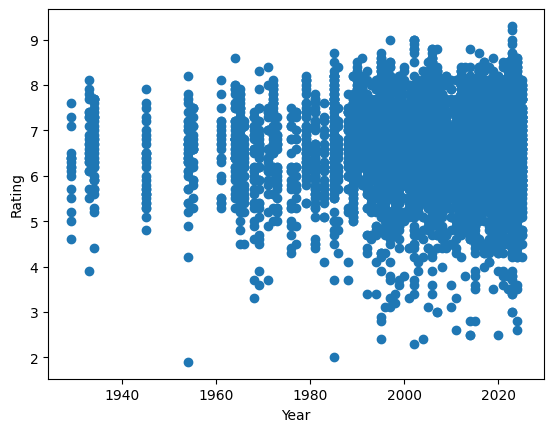

In [258]:
#display relation between rating and year
plt.scatter(df['Year'], df['Rating'])
plt.xlabel("Year")
plt.ylabel("Rating")
plt.show()

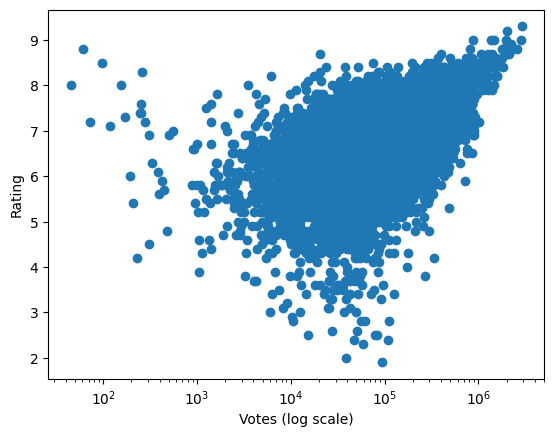

In [259]:
#display relation between rating and Votes
plt.scatter(df['VotesCount'], df['Rating'])
plt.xscale("log")
plt.xlabel("Votes (log scale)")
plt.ylabel("Rating")
plt.show()

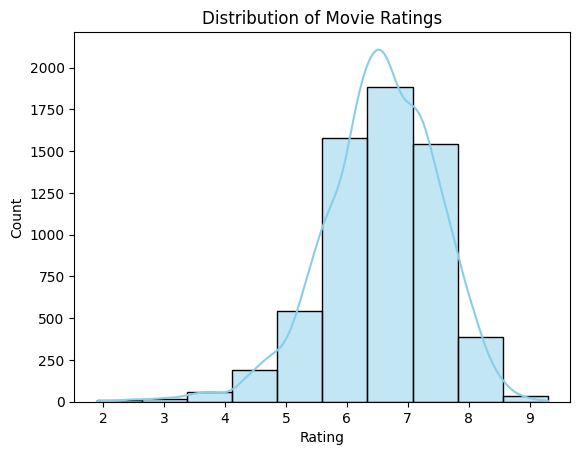

In [260]:
#display rating intervals with seaborn 
import seaborn as sns
sns.histplot(df['Rating'], bins=10, kde=True, color='skyblue')
plt.xlabel("Rating")     
plt.ylabel("Count")      
plt.title("Distribution of Movie Ratings") 
plt.show()

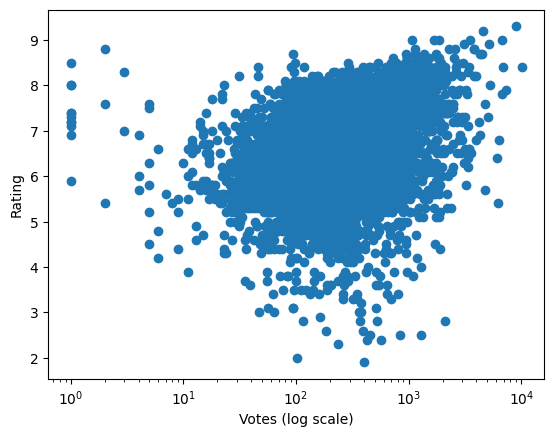

In [261]:

#display relation between rating and ReviewCount
plt.scatter(df['ReviewCount'], df['Rating'])
plt.xscale("log")
plt.xlabel("Votes (log scale)")
plt.ylabel("Rating")
plt.show()

handle outliers

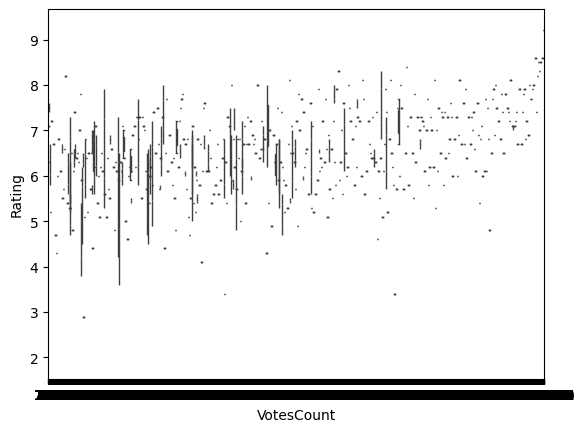

In [262]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['VotesCount'],y=df['Rating'])
plt.show()

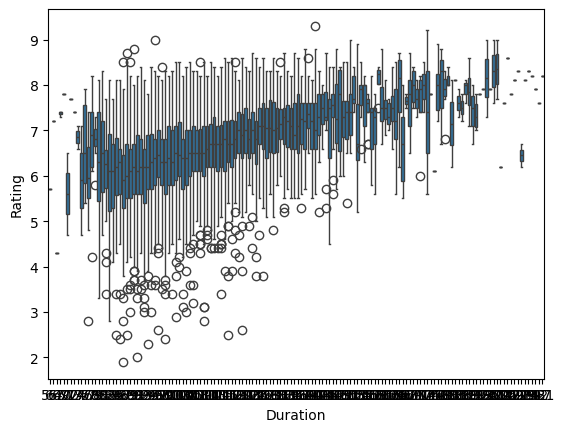

In [263]:

sns.boxplot(x=df['Duration'],y=df['Rating'])
plt.show()

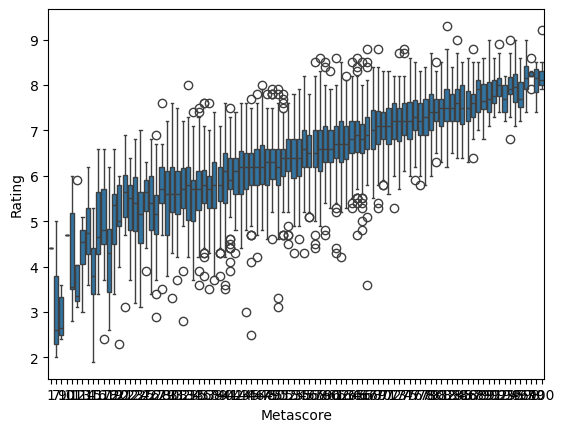

In [264]:
sns.boxplot(x=df['Metascore'],y=df['Rating'])
plt.show()

In [265]:
chossen_cols = ['VotesCount', 'Metascore', 'Duration']
df_clean = df.copy()

for col in chossen_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # This line automatically checks ALL rows for this column
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]


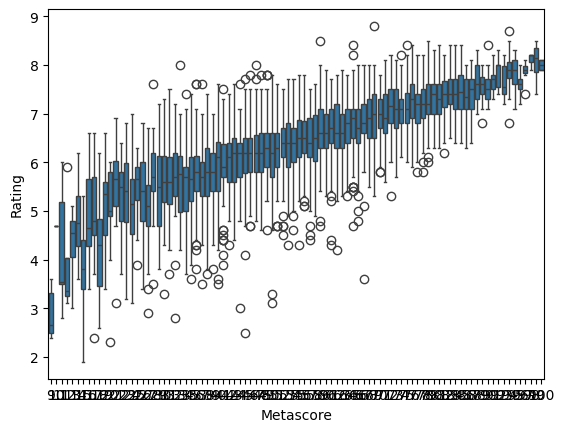

In [266]:
sns.boxplot(x=df_clean['Metascore'], y=df_clean['Rating'])
plt.show()

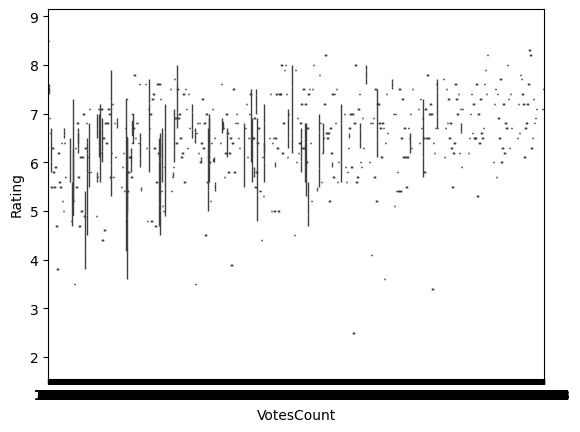

In [267]:
sns.boxplot(x=df_clean['VotesCount'], y=df_clean['Rating'])
plt.show()

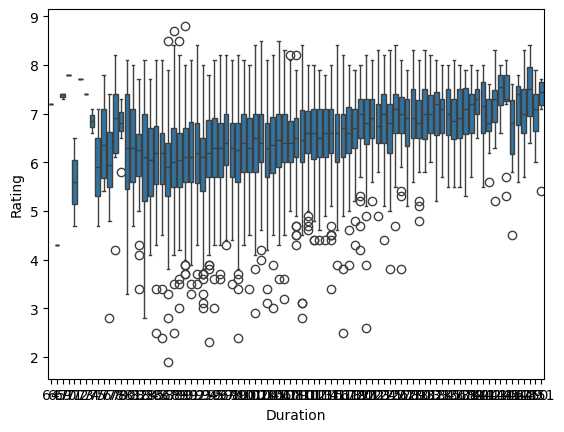

In [268]:
sns.boxplot(x=df_clean['Duration'], y=df_clean['Rating'])
plt.show()

In [269]:
df_clean.shape

(5513, 15)

### Feature Selection

In [270]:
X = df_clean[['Metascore','VotesCount','Duration']]
y = df_clean['Rating']

**Handle skewed numeric columns (log-transform Votes & ReviewCount)**

In [271]:
X['VotesCount'] = np.log1p(X['VotesCount'])
X['Duration'] = np.log1p(X['Duration'])
X['Metascore'] = np.log1p(X['Metascore'])

C:\Users\user\AppData\Local\Temp\ipykernel_14816\2664977657.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['VotesCount'] = np.log1p(X['VotesCount'])
C:\Users\user\AppData\Local\Temp\ipykernel_14816\2664977657.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Duration'] = np.log1p(X['Duration'])
C:\Users\user\AppData\Local\Temp\ipykernel_14816\2664977657.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

### Model fit and training using LinearRegression

**Import linear regression model estimator from scikit-learn and instantiate**

In [272]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import accuracy_score

In [273]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [274]:
##train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

**Evaluate**

In [278]:
from sklearn.metrics import mean_squared_error

pred = model.predict(X_test)
mse = mean_squared_error(y_test, pred)
print("MSE:", mse)
rmse = np.sqrt(0.3119)
print("RMSE:",rmse)

MSE: 0.3097661602150733
RMSE: 0.5584800802177281


In [277]:
y_pred = model.predict(X_train) 
from sklearn import metrics

r2 = metrics.r2_score(y_train, y_pred)
print("R-squared value of this fit:", round(r2, 3))

R-squared value of this fit: 0.56


### Model fit and training using Random Forest

In [279]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [280]:
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

In [281]:
# MSE & RMSE
mse = metrics.mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)

# R² score
r2 = metrics.r2_score(y_test, y_pred_test)

print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

MSE: 0.364
RMSE: 0.603
R²: 0.498


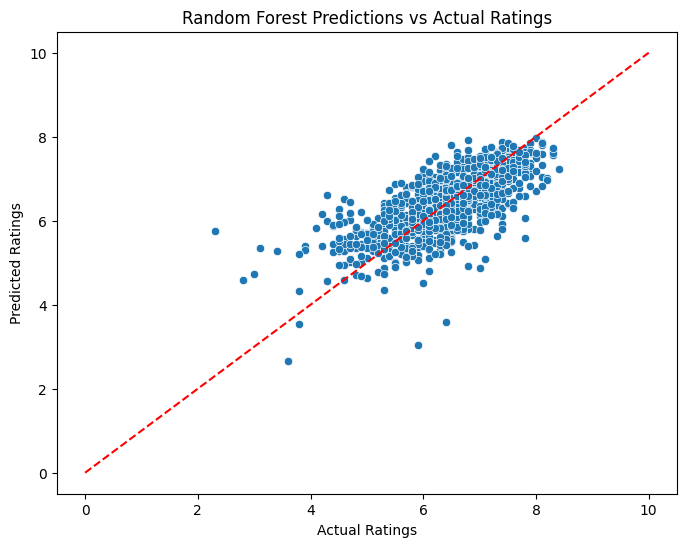

In [282]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_test)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Random Forest Predictions vs Actual Ratings")
plt.plot([0,10], [0,10], color='red', linestyle='--')  # perfect prediction line
plt.show()